## AI/ML Techniques for the Statistical Inference:


### Use of Neural Network Architures in Bayesian Parameter Inference

#### Understanding the Training Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

plt.style.use( './my_code/presentation_plot.mplstyle')



In [2]:
parameters = np.loadtxt('./data/Parameters.txt', skiprows=1)

xHI = parameters[:,0]
input_params = parameters[:,1:]

k_values = np.loadtxt('./data/K_vals.txt',skiprows=1)
delta_PS = np.loadtxt('./data/Power_Spectrum_Normalised.txt',skiprows=1)

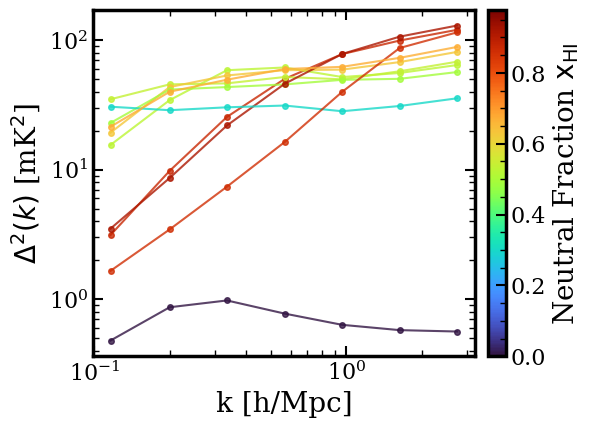

In [3]:
# Plotting the power spectrum for different xHI values

num = 10

fig, ax = plt.subplots(figsize=(6, 4.5))

cmap = plt.cm.turbo
norm = plt.Normalize(vmin=min(xHI), vmax=max(xHI))

for i in range(num):
    ax.plot(k_values, delta_PS[i],
            color=cmap(norm(xHI[i])),
            label=f'xHI={xHI[i]}',
            alpha=0.8,
            linewidth=1.5,
            marker='o',
            markersize=4
            )

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, label=r'Neutral Fraction $\rm x_{{HI}}$', pad=0.03,)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel(r'$\Delta^2(k)$ [mK$^2$]')

# plt.legend(fontsize=8, ncol=2)
plt.show()

#### Building ANN Emulator

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch

from my_code.ann import TrainANN

In [17]:
len(input_params)

7204

In [55]:
train_num = 7000
input_train = input_params[:train_num]
delta_PS_train = delta_PS[:train_num]

x_train, x_val, y_train, y_val = train_test_split(input_train, delta_PS_train, test_size=0.2, random_state=67)

In [56]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train = x_scaler.fit_transform(x_train)
x_val   = x_scaler.transform(x_val)


In [57]:
training_data = [x_train, y_train]
validation_data = [x_val, y_val]



In [58]:
train_loss, val_loss = TrainANN(training_data, validation_data, )

Using GPU: NVIDIA RTX A4000
Starting training...
Epoch    0 | Train 737.677217 | Val 200.825633
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 0 with loss: 200.825633)
Epoch    1 | Train 130.969779 | Val 83.540117
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 1 with loss: 83.540117)
Epoch    2 | Train 54.591087 | Val 41.018552
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 2 with loss: 41.018552)
Epoch    3 | Train 31.472099 | Val 29.252651
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 3 with loss: 29.252651)
Epoch    4 | Train 24.176462 | Val 23.849271
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 4 with loss: 23.849271)
Epoch    5 | Train 19.703670 | Val 19.141390
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 5 with loss: 19.141390)
Epoch    6 | Train 16.464063 | Val 15.982408
--> Saved checkpoint: ANN_model/best_model.pth  at epoch: 6 with loss: 15.982408)
Epoch    7 | Train 13.961716 | Val 13.315006
--> Saved che

#### Artificial Neural Networks (ANN) as an Emulator

In [59]:
len(train_loss)

100

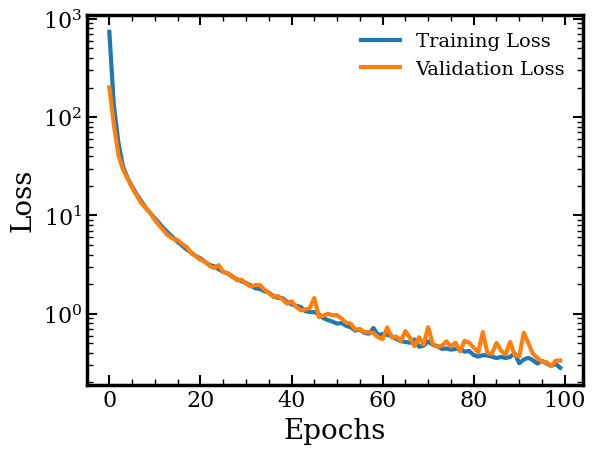

In [60]:
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.ylim(0, 500)
plt.legend()
plt.show()

In [61]:
model = torch.load('./ANN_model/best_model.pth', weights_only=True)
model["epoch"]
model["loss"]



0.2932447239079259

In [62]:
from my_code.ann import ANN

In [63]:
ann_model = ANN().to('cuda')
ann_model.load_state_dict(model["model_state_dict"],)
ann_model.eval()

ANN(
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=7, bias=True)
)

Predicted Power Spectrum:
[[ 3.20816727e+01  2.78660526e+01  2.82268696e+01  2.94747753e+01
   2.61183643e+01  2.83596821e+01  3.24106064e+01]
 [ 1.45571384e+01  3.33695908e+01  4.71277008e+01  6.08530807e+01
   6.75840759e+01  7.88161469e+01  9.69691849e+01]
 [ 2.62015724e+01  2.27490234e+01  2.41293373e+01  2.42354355e+01
   2.21048889e+01  2.36081486e+01  2.69142208e+01]
 [ 2.19796270e-01  3.68006200e-01 -5.45249395e-02  1.35290354e-01
  -1.55713975e-01  1.47045404e-01  4.93534803e-02]
 [ 1.48480425e+01  3.39484062e+01  5.85381203e+01  6.17537613e+01
   5.23861465e+01  5.66986923e+01  6.58915024e+01]]
True Power Spectrum:
[[32.16828567 27.77689944 28.43390465 29.3323964  26.50911658 28.42218066
  32.432407  ]
 [14.43369645 33.12086684 47.03021553 61.25208227 67.97339949 79.09335132
  97.08916329]
 [25.50175669 22.85143049 23.82278386 24.72323676 22.57249341 23.66760317
  26.89306846]
 [ 0.          0.          0.          0.          0.          0.
   0.        ]
 [15.04864113 33.88

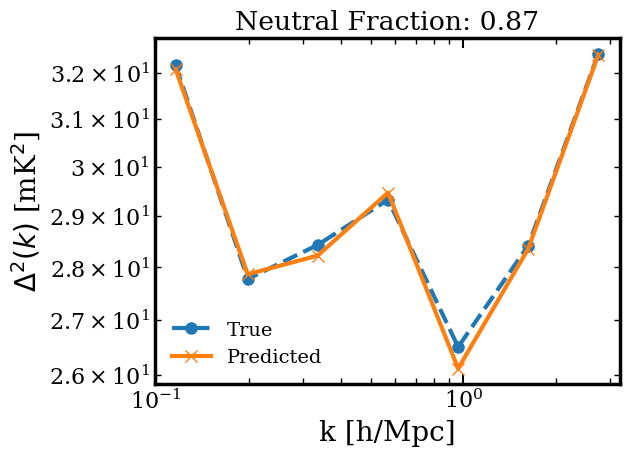

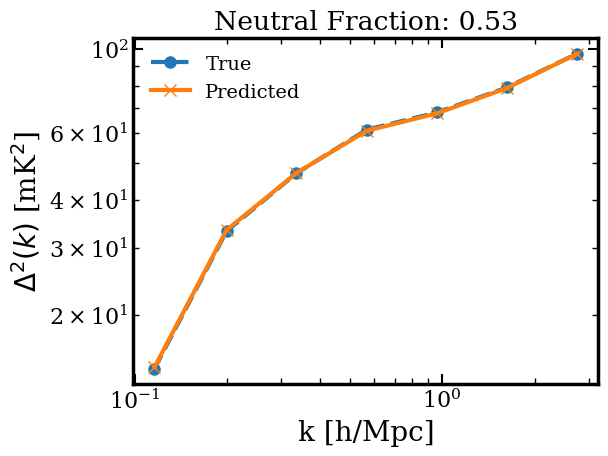

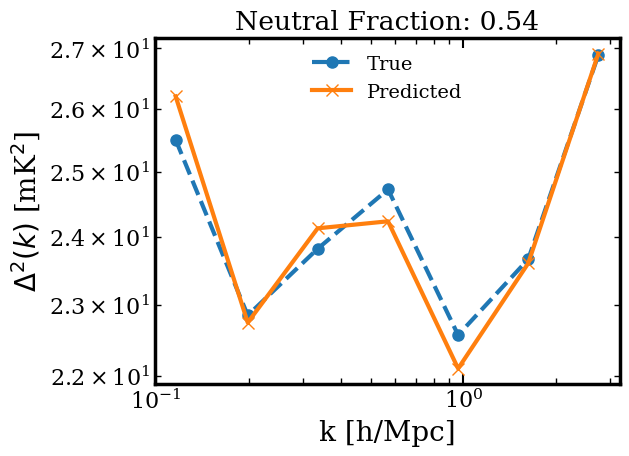

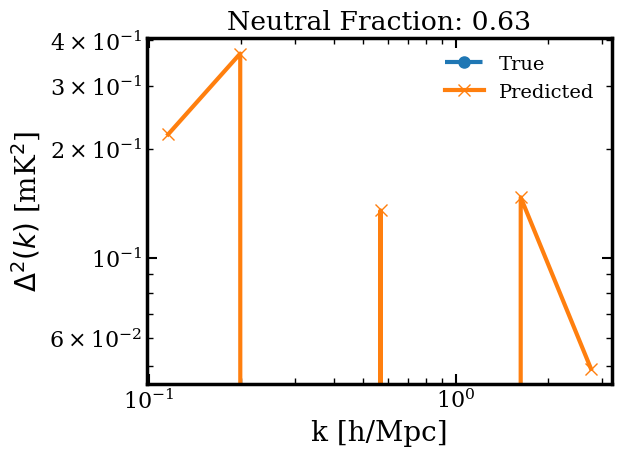

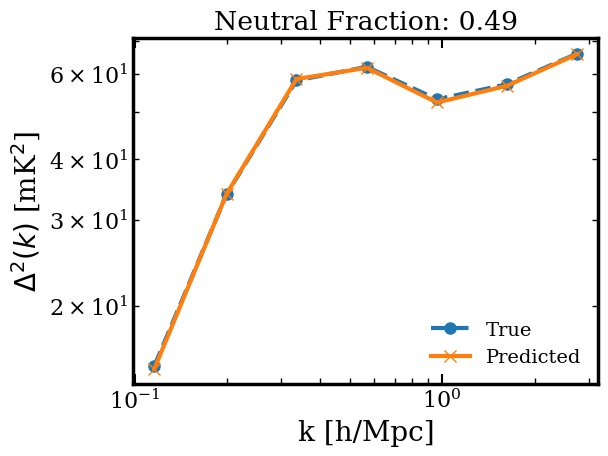

In [64]:
x_test = x_val[:5]
y_test = y_val[:5]

x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to('cuda')
with torch.no_grad():
    y_pred_tensor = ann_model(x_test_tensor)

y_pred = y_pred_tensor.cpu().numpy()
print("Predicted Power Spectrum:")
print(y_pred)
print("True Power Spectrum:")
print(y_test)

# Plotting the predicted vs true power spectrum for the test set

for i in range(len(x_test)):
    plt.figure(figsize=(6, 4.5))
    plt.plot(k_values, y_test[i], label=f'True', linestyle='--', marker='o')
    plt.plot(k_values, y_pred[i], label=f'Predicted', linestyle='-', marker='x')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('k [h/Mpc]')
    plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')
    plt.legend()
    plt.title("Neutral Fraction: {:.2f}".format(xHI[i]))
    plt.show()


#### Bayesian Neural Network (BNN) as an Emulator

### Simulation-Based Inference (SBI)